In [ ]:
import requests
import re
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score, auc, roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os
import requests
import io

In [ ]:
#Parameters
Iterations = 5120 # number of iterations for Logistic Regression
random = 25 # random state for Logistic Regression

In [ ]:
# Load Data
api_url = "https://api.github.com/repos/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/contents/ProcessedData/processed_tournament_data_clean.csv"
os.makedirs("processed", exist_ok=True)

response = requests.get(api_url)

if response.status_code == 200:
    file = response.json()
    download_url = file["download_url"]

    csv_data = requests.get(download_url).content
    tournament_data = pd.read_csv(io.BytesIO(csv_data))

    print("Loaded into DataFrame successfully")
else:
    raise Exception(f"Failed to access API: {response.status_code}")




Loaded into DataFrame successfully


In [ ]:
TARGET = "Win"

FEATURES = [ # Core signal features: seeds, efficiency, rebounding, turnovers, ratings, grades.
   "T1AverageFTA", "T1AverageFTM", "T1AverageBlk",
   "T2AverageFTA", "T2AverageFTM", "T2AverageBlk"
]

fill_vals = {
    "T1Seed": 17, "T2Seed": 17, "SeedDifference": 0,
    "T1Rating": 1000, "T2Rating": 1000, "RatingDifference": 0,
    "T1Grade": 0, "T2Grade": 0, "GradeDifference": 0,
}

for col in FEATURES:
    if col in fill_vals:
        tournament_data[col] = tournament_data[col].fillna(fill_vals[col])
    else:
        med = tournament_data[col].median()
        tournament_data[col] = tournament_data[col].fillna(med)

column_medians = {}
for col in FEATURES:
    if col not in fill_vals:
        column_medians[col] = tournament_data[col].median()

x = tournament_data[FEATURES]
y = tournament_data[TARGET]

groups = tournament_data["Season"]
seasons = tournament_data["Season"].unique()

gkf = GroupKFold(n_splits=len(seasons))

In [ ]:
model = LogisticRegression(max_iter=Iterations, random_state=random)

cv_results = []

for season_index, (train_index, test_index) in enumerate(gkf.split(x, y, groups)):
    test_season = groups.iloc[test_index].unique()[0]
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_fold = clone(model)
    model_fold.fit(x_train, y_train)

    y_pred = model_fold.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred_prob = model_fold.predict_proba(x_test)[:, 1]
    log_loss_score = log_loss(y_test, y_pred_prob)
    brier_score = brier_score_loss(y_test, y_pred_prob)
    fold_auc = roc_auc_score(y_test, y_pred_prob)

    cv_results.append({
        "Season": test_season,
        "Accuracy": accuracy,
        "LogLoss": log_loss_score,
        "BrierScore": brier_score,
        "AUC": fold_auc,
    })


df_cv_results = pd.DataFrame(cv_results)
df_cv_results = df_cv_results.sort_values("Season")

for _, row in df_cv_results.iterrows():
    print(f"Season {int(row['Season'])}: Accuracy = {row['Accuracy']:.3f}, Log Loss = {row['LogLoss']:.3f}, Brier Score = {row['BrierScore']:.3f}")

print(model.fit(x, y).score(x, y))

print(f"\nAverage Accuracy: {df_cv_results['Accuracy'].mean():.3f}")
print(f"Average Log Loss: {df_cv_results['LogLoss'].mean():.3f}")
print(f"Average Brier Score: {df_cv_results['BrierScore'].mean():.3f}")
print(f"\nAverage AUC: {df_cv_results['AUC'].mean():.3f}")

Season 2003: Accuracy = 0.672, Log Loss = 0.627, Brier Score = 0.219
Season 2004: Accuracy = 0.594, Log Loss = 0.632, Brier Score = 0.223
Season 2005: Accuracy = 0.562, Log Loss = 0.699, Brier Score = 0.251
Season 2006: Accuracy = 0.562, Log Loss = 0.650, Brier Score = 0.227
Season 2007: Accuracy = 0.578, Log Loss = 0.669, Brier Score = 0.238
Season 2008: Accuracy = 0.578, Log Loss = 0.645, Brier Score = 0.224
Season 2009: Accuracy = 0.609, Log Loss = 0.687, Brier Score = 0.245
Season 2010: Accuracy = 0.591, Log Loss = 0.641, Brier Score = 0.225
Season 2011: Accuracy = 0.569, Log Loss = 0.655, Brier Score = 0.232
Season 2012: Accuracy = 0.662, Log Loss = 0.618, Brier Score = 0.215
Season 2013: Accuracy = 0.608, Log Loss = 0.672, Brier Score = 0.239
Season 2014: Accuracy = 0.562, Log Loss = 0.658, Brier Score = 0.235
Season 2015: Accuracy = 0.569, Log Loss = 0.664, Brier Score = 0.236
Season 2016: Accuracy = 0.623, Log Loss = 0.644, Brier Score = 0.227
Season 2017: Accuracy = 0.623, Log

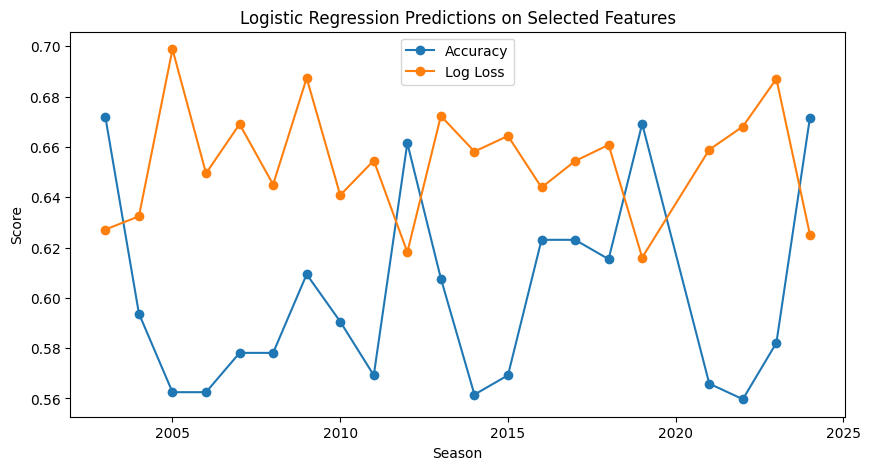

In [ ]:
#Plot results to graph
plt.figure(figsize=(10, 5))
plt.plot(df_cv_results['Season'], df_cv_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_cv_results['Season'], df_cv_results['LogLoss'], marker='o', label='Log Loss')
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("Logistic Regression Predictions on Selected Features")
plt.legend()
plt.show()

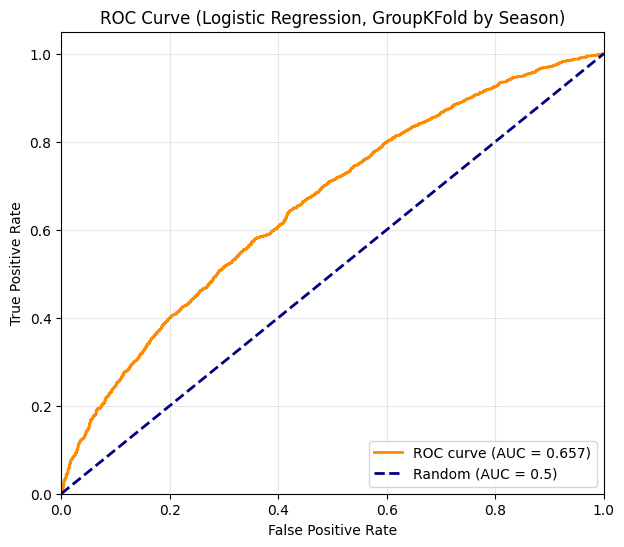

In [ ]:
cv_probs = cross_val_predict(
    LogisticRegression(max_iter=Iterations, random_state=random),
    x, y, cv=gkf, groups=groups, method='predict_proba'
)[:, 1]

fpr, tpr, thresholds = roc_curve(y, cv_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression, GroupKFold by Season)')
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.show()

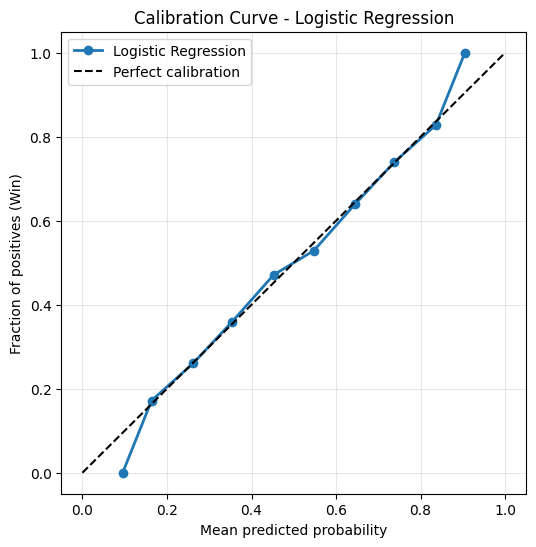

In [ ]:
prob_true, prob_pred = calibration_curve(y, cv_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (Win)')
plt.title('Calibration Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

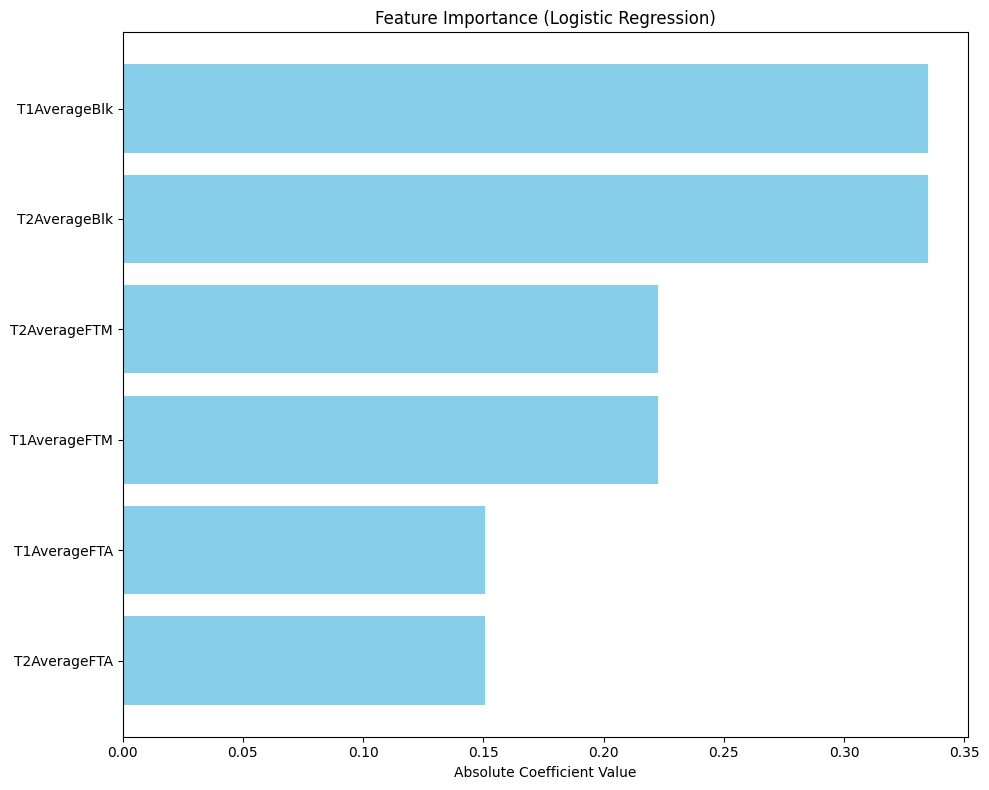

In [ ]:
feature_names = FEATURES
coefficients = model.coef_[0]

importance = np.abs(coefficients)

sorted_idx = np.argsort(importance)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = importance[sorted_idx]

plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_importance, color='skyblue')
plt.xlabel("Absolute Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

In [ ]:
api_url = "https://api.github.com/repos/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/contents/ProcessedData/predictions_merged.csv"
os.makedirs("processed", exist_ok=True)

response = requests.get(api_url)

if response.status_code == 200:
    file = response.json()
    download_url = file["download_url"]

    csv_data = requests.get(download_url).content
    sample_submission = pd.read_csv(io.BytesIO(csv_data))

    print("Loaded into DataFrame successfully")
else:
    raise Exception(f"Failed to access API: {response.status_code}")


Loaded into DataFrame successfully


In [ ]:
for col in FEATURES:
    if col in fill_vals:
        sample_submission[col] = sample_submission[col].fillna(fill_vals[col])
    else:
        sample_submission[col] = sample_submission[col].fillna(column_medians[col])

x_new = sample_submission[FEATURES]
sample_submission["Pred"] = model.predict_proba(x_new)[:, 1]
sample_submission[['ID', 'Pred']].to_csv("LogisticRegressionPredictions.csv", index=False)